In [52]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [53]:
df=pd.read_csv("Downloads/Electric_Vehicle_Population_Data.csv/Electric_Vehicle_Population_Data.csv")

In [54]:
df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,5.306701e+10
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,5.302997e+10
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EBXL,King,Seattle,WA,98134.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,6336319,POINT (-122.32981499999994 47.579810000000066),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,5YJSA1CP0D,Snohomish,Edmonds,WA,98020.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,186212960,POINT (-122.37507 47.80807000000004),PUGET SOUND ENERGY INC,5.306105e+10


In [55]:
df.shape

(135038, 17)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135030 non-null  object 
 2   City                                               135030 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135030 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              134789 non-null  object 
 8   Electric Vehicle Type                              135038 non-null  object

In [57]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 8
City                                                   8
State                                                  0
Postal Code                                            8
Model Year                                             0
Make                                                   0
Model                                                249
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         1
Base MSRP                                              1
Legislative District                                 312
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       8
2020 Census Tract                                      8
dtype: int64

In [58]:
#Handling Missing Values And Renaming Columns 

req_col = ["VIN (1-10)",
           'County',
           "City",
           "State",
           "Model Year",
           "Make",
           "Model",
           "Electric Vehicle Type",
           "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
           "Electric Range",
           "Base MSRP",
           "Legislative District",
           "Electric Utility"] 
df=df[req_col]



In [59]:

df=df.rename(columns={
    "VIN (1-10)":"vin_(1-10)",
    "County":"County",
    "City":"city",
    "State":"state",
    "Model Year":"model_year",
    "Make":"make",
    "Model":"model",
    "Electric Vehicle Type":"electric_vehicle_type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility":"cafv_eligibility",
    "Electric Range":"electric_range",
    "Base MSRP":"msrp",
    "Legislative District":"legislative_district",
    "Electric Utility":"electric_utility"
})



In [60]:
df.head(2)

,vin_(1-10),County,city,state,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,msrp,legislative_district,electric_utility
0,5YJ3E1EA0K,Thurston,Tumwater,WA,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,PUGET SOUND ENERGY INC
1,1N4BZ1DV4N,Island,Clinton,WA,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,PUGET SOUND ENERGY INC


In [61]:

text_columns= [
    "County",
    "city",
    "state",
    "make",
    "electric_vehicle_type",
    "cafv_eligibility",
    "electric_utility",
    "model"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

In [62]:
df.head(5)

,vin_(1-10),County,city,state,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,msrp,legislative_district,electric_utility
0,5YJ3E1EA0K,Thurston,Tumwater,Wa,2019,Tesla,Model 3,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,Puget Sound Energy Inc
1,1N4BZ1DV4N,Island,Clinton,Wa,2022,Nissan,Leaf,Battery Electric Vehicle (Bev),Eligibility Unknown As Battery Range Has Not B...,0.0,0.0,10.0,Puget Sound Energy Inc
2,5YJ3E1EA0L,Snohomish,Snohomish,Wa,2020,Tesla,Model 3,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,Puget Sound Energy Inc
3,5YJ3E1EBXL,King,Seattle,Wa,2020,Tesla,Model 3,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,City Of Seattle - (Wa)|City Of Tacoma - (Wa)
4,5YJSA1CP0D,Snohomish,Edmonds,Wa,2013,Tesla,Model S,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,Puget Sound Energy Inc


In [63]:
missing_report = df.isnull().sum().sort_values(ascending = False)
missing_report

legislative_district     312
electric_range             1
msrp                       1
County                     0
vin_(1-10)                 0
model_year                 0
state                      0
city                       0
make                       0
cafv_eligibility           0
electric_vehicle_type      0
model                      0
electric_utility           0
dtype: int64

In [64]:
df=df.dropna(subset=["city","County","model"])


In [65]:
df.shape


(135038, 13)

In [66]:
df["electric_range"]=df["electric_range"].fillna(df["electric_range"].median())
df["msrp"] = df["msrp"].fillna(df["msrp"].median())

In [67]:
df[["msrp","electric_range"]].isnull().sum()

msrp              0
electric_range    0
dtype: int64

In [68]:
df["electric_utility"]=df["electric_utility"].fillna("Not Available")

In [69]:
df["legislative_district"]=df["legislative_district"].fillna("Unknown")

In [70]:
df.isnull().sum()

vin_(1-10)               0
County                   0
city                     0
state                    0
model_year               0
make                     0
model                    0
electric_vehicle_type    0
cafv_eligibility         0
electric_range           0
msrp                     0
legislative_district     0
electric_utility         0
dtype: int64

In [71]:
# Duplicate Handling 

df.duplicated(subset="vin_(1-10)").sum()

np.int64(125979)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   vin_(1-10)             135038 non-null  object 
 1   County                 135038 non-null  object 
 2   city                   135038 non-null  object 
 3   state                  135038 non-null  object 
 4   model_year             135038 non-null  int64  
 5   make                   135038 non-null  object 
 6   model                  135038 non-null  object 
 7   electric_vehicle_type  135038 non-null  object 
 8   cafv_eligibility       135038 non-null  object 
 9   electric_range         135038 non-null  float64
 10  msrp                   135038 non-null  float64
 11  legislative_district   135038 non-null  object 
 12  electric_utility       135038 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 13.4+ MB


In [73]:
for col in df.select_dtypes(include="object").columns:
    print(F"\n{col}")
    print(df[col].nunique())




vin_(1-10)
9059

County
170

city
651

state
46

make
36

model
126

electric_vehicle_type
2

cafv_eligibility
3

legislative_district
50

electric_utility
77


In [74]:
df.head(5)

,vin_(1-10),County,city,state,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,msrp,legislative_district,electric_utility
0,5YJ3E1EA0K,Thurston,Tumwater,Wa,2019,Tesla,Model 3,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,Puget Sound Energy Inc
1,1N4BZ1DV4N,Island,Clinton,Wa,2022,Nissan,Leaf,Battery Electric Vehicle (Bev),Eligibility Unknown As Battery Range Has Not B...,0.0,0.0,10.0,Puget Sound Energy Inc
2,5YJ3E1EA0L,Snohomish,Snohomish,Wa,2020,Tesla,Model 3,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,Puget Sound Energy Inc
3,5YJ3E1EBXL,King,Seattle,Wa,2020,Tesla,Model 3,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,City Of Seattle - (Wa)|City Of Tacoma - (Wa)
4,5YJSA1CP0D,Snohomish,Edmonds,Wa,2013,Tesla,Model S,Battery Electric Vehicle (Bev),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,Puget Sound Energy Inc


In [78]:
df["legislative_district"]=(df["legislative_district"].astype(str).str.replace(".0","",regex = False))

In [79]:
df["legislative_district"].value_counts()

legislative_district
41         9035
45         8353
48         7637
36         5961
1          5746
5          5669
46         5433
43         5320
11         4575
37         4137
34         4039
18         3583
44         3318
22         3285
21         3238
32         3235
40         3075
23         3036
26         2696
33         2628
10         2389
31         2359
47         2318
17         2316
27         1959
39         1944
24         1933
49         1879
35         1878
42         1872
28         1778
30         1547
2          1452
8          1426
25         1320
38         1263
6          1217
12         1217
20         1154
4          1048
13          889
14          874
29          855
19          784
9           735
16          705
3           666
7           633
15          317
Unknown     312
Name: count, dtype: int64

In [82]:
df.isnull().sum()

vin_(1-10)               0
County                   0
city                     0
state                    0
model_year               0
make                     0
model                    0
electric_vehicle_type    0
cafv_eligibility         0
electric_range           0
msrp                     0
legislative_district     0
electric_utility         0
dtype: int64

In [83]:
data = df.copy(deep=True)

In [84]:
data.shape

(135038, 13)

In [85]:
data.to_csv("ev_cleaned.csv", index = False)

In [95]:
data["model_year"].value_counts()

model_year
2022    27983
2023    22476
2021    18554
2018    14343
2020    11151
2019    10577
2017     8579
2016     5688
2015     4925
2013     4598
2014     3601
2012     1657
2011      815
2024       30
2010       23
2008       20
2000        9
1999        4
2002        2
1998        1
2003        1
1997        1
Name: count, dtype: int64

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   vin_(1-10)             135038 non-null  object 
 1   County                 135038 non-null  object 
 2   city                   135038 non-null  object 
 3   state                  135038 non-null  object 
 4   model_year             135038 non-null  int64  
 5   make                   135038 non-null  object 
 6   model                  135038 non-null  object 
 7   electric_vehicle_type  135038 non-null  object 
 8   cafv_eligibility       135038 non-null  object 
 9   electric_range         135038 non-null  float64
 10  msrp                   135038 non-null  float64
 11  legislative_district   135038 non-null  object 
 12  electric_utility       135038 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 13.4+ MB






EDA - QUESTION -1
    -----EV Adoption Over Time





In [99]:
ev_by_year = (
    data.groupby("model_year").size().reset_index(name="ev_count").sort_values("model_year")
)
ev_by_year.tail()

,model_year,ev_count
17,2020,11151
18,2021,18554
19,2022,27983
20,2023,22476
21,2024,30


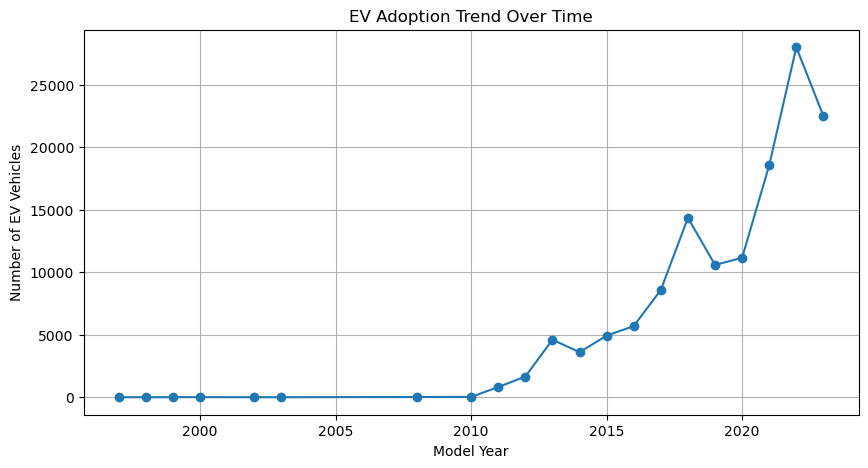

In [103]:
ev_by_year_clean = ev_by_year[ev_by_year["model_year"]<=2023]


plt.figure(figsize=(10,5))
plt.plot(ev_by_year_clean["model_year"],ev_by_year_clean["ev_count"],marker = "o")
plt.xlabel("Model Year")
plt.ylabel("Number of EV Vehicles")
plt.title("EV Adoption Trend Over Time")
plt.grid(True)
plt.show()

INSIGHT : 

- EV registrations grew rapidly from 2020 to 2023.
       
- Apparent decline in 2024 is due to incomplete data, not real market contraction.
       
RECOMMANDATION : 

- Continue investments in  : (charging infrastruture and EV inventory planning)
       
- TO BE NOTED : EV demand is still strong ; recent dip is a data artifact.

EDA - QUESTION -2
    -----EV Geographical concentrated data 
    

In [105]:
ev_by_country=(
    data.groupby("County").size().reset_index(name="ev_count").sort_values("ev_count",ascending = False)
)

ev_by_country.head(11)

,County,ev_count
73,King,70842
143,Snohomish,15258
113,Pierce,10410
25,Clark,7997
156,Thurston,4851
75,Kitsap,4461
146,Spokane,3326
164,Whatcom,3315
10,Benton,1688
141,Skagit,1504


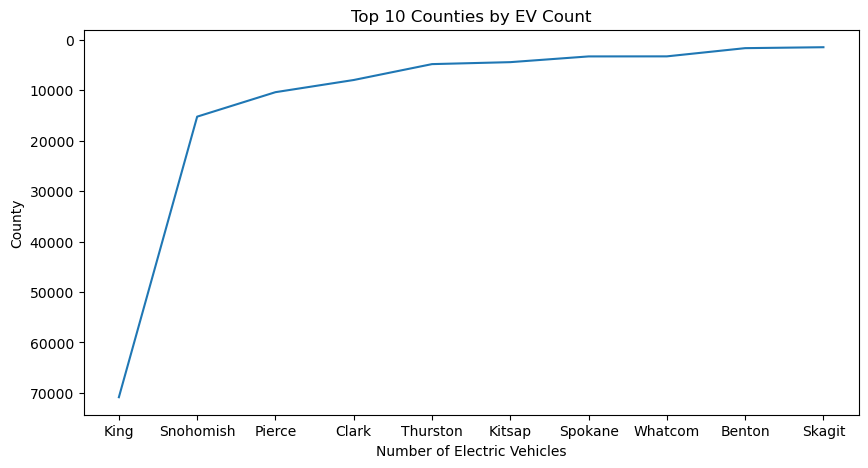

In [106]:
top10_counties = ev_by_country.head(10)
plt.figure(figsize=(10,5))
plt.plot(top10_counties["County"],top10_counties["ev_count"])
plt.xlabel("Number of Electric Vehicles")
plt.ylabel("County")
plt.title("Top 10 Counties by EV Count")
plt.gca().invert_yaxis()
plt.show()

In [107]:
ev_by_city = (
    data.groupby("city").size().reset_index(name="ev_count").sort_values("ev_count",ascending = False)

)

In [121]:
ev_by_city.head(11)

,city,ev_count
510,Seattle,23489
42,Bellevue,6960
463,Redmond,4965
606,Vancouver,4819
274,Kirkland,4201
54,Bothell,4196
493,Sammamish,3950
464,Renton,3516
401,Olympia,3228
570,Tacoma,2846


INSIGHT:

-- EV adotion is Highly Concentarted
       
-- Top counties/cities(King , Seattle , Bellevue) dominate registrations

RECOMMENDATION:

--Prioritize : charging stations
             ,EV service centers
             , Marketing compaigns in high density EV regions
                     
-- use low-adoption region for future expansion with incentives


--  Focusing on resources where adoption is already strong , while strategically growing new markets.  

EDA - QUESTION - 3
    -----Which EV Manufacturers and models dominate the Market.

In [135]:
## EV Manufactures Dominance

make_counts = (
    data["make"].value_counts().reset_index().rename(columns = {"index":"make","make":"ev_count"})
)
make_counts.head(11)

,ev_count,count
0,Tesla,61808
1,Nissan,13150
2,Chevrolet,11437
3,Ford,6897
4,Bmw,5895
5,Kia,5491
6,Toyota,4883
7,Volkswagen,3526
8,Volvo,3221
9,Audi,2727


In [137]:
## Ev Model Dominance

model_counts = (
    data["model"].value_counts().reset_index().rename(columns = {"index":"model","model":"ev_count"})
)

model_counts.head(11)

,ev_count,count
0,Model 3,25837
1,Model Y,23577
2,Leaf,13020
3,Model S,7473
4,Bolt Ev,5419
5,Volt,4881
6,Model X,4874
7,Niro,2609
8,Id.4,2480
9,Prius Prime,2473


In [138]:
## EV Type (BEV VS PHEV)

ev_type_counts = (
    data["electric_vehicle_type"].value_counts().reset_index().rename(columns = {"index":"electric_vehicle_type","electric_vehicle_type":"ev_count"})
)

ev_type_counts.head(11)

,ev_count,count
0,Battery Electric Vehicle (Bev),103882
1,Plug-In Hybrid Electric Vehicle (Phev),31156


INSIGHT : 

  --Telsa dominates both manufacturer and model rankings ,few models account for the majority of EV registrations
    

EDA - QUESTION - 4 ----- Relationship between Electric range , MSRP (PRICE) , and EV Adoption

In [146]:
data[["electric_range","msrp"]].describe()

,electric_range,msrp
count,135038.000000,135038.000000
mean,74.591567,1448.396599
std,98.743862,9683.623084
min,0.000000,0.000000
25%,0.000000,0.000000
50%,21.000000,0.000000
75%,150.000000,0.000000
max,337.000000,845000.000000


In [147]:
data[data["msrp"] == 0].shape

(131613, 13)

In [150]:
price_range = data[(data["msrp"]>0) & (data["electric_range"]>0)]

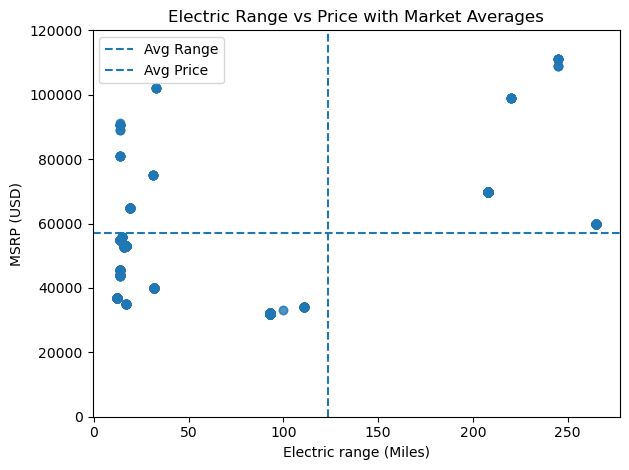

In [153]:
avg_range = price_range["electric_range"].mean()
avg_price = price_range["msrp"].mean()

plt.figure()
plt.scatter(
    price_range["electric_range"],
    price_range["msrp"],
    alpha=0.4
)

plt.axvline(avg_range , linestyle = "--", label = "Avg Range")
plt.axhline(avg_price , linestyle = "--", label = "Avg Price")


plt.ylim(0,120000)
plt.xlabel("Electric range (Miles)")
plt.ylabel("MSRP (USD)")
plt.title("Electric Range vs Price with Market Averages")
plt.legend()
plt.tight_layout()
plt.show()

INSIGHT:

   -- Most EV fall in (200-300) miles range.
   
   -- $30k - $60k msrp.
   
   -- extreme high - priced EVs are rare and non-represntative.

RECOMMENDATION:

   -- Manufactires should Optimize models for value-for-money range.
   
   -- policy-makers should incentivize mid-range EVs for mass adoption.

-- Consumers prioritize practical range and affordablity over maximum performance.

EDA - QUESTION - 5 -- CAFV POLICY IMPACT ON EV ADOPTION

In [154]:
cafv_counts = data["cafv_eligibility"].value_counts()
cafv_counts

cafv_eligibility
Clean Alternative Fuel Vehicle Eligible                         61221
Eligibility Unknown As Battery Range Has Not Been Researched    56983
Not Eligible Due To Low Battery Range                           16834
Name: count, dtype: int64

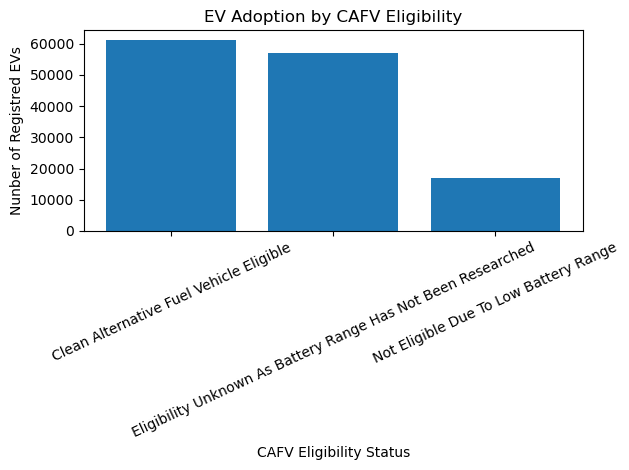

In [159]:
plt.figure()
plt.bar(cafv_counts.index,cafv_counts.values)
plt.xticks(rotation = 25)
plt.xlabel("CAFV Eligibility Status")
plt.ylabel("Nunber of Registred EVs")
plt.title("EV Adoption by CAFV Eligibility")
plt.tight_layout()
plt.show()

In [161]:
cafv_evtype = (
    data.groupby(["cafv_eligibility","electric_vehicle_type"]).size().unstack()
)
cafv_evtype

electric_vehicle_type,Battery Electric Vehicle (Bev),Plug-In Hybrid Electric Vehicle (Phev)
cafv_eligibility,,
Clean Alternative Fuel Vehicle Eligible,46889.0,14332.0
Eligibility Unknown As Battery Range Has Not Been Researched,56983.0,NaN
Not Eligible Due To Low Battery Range,10.0,16824.0


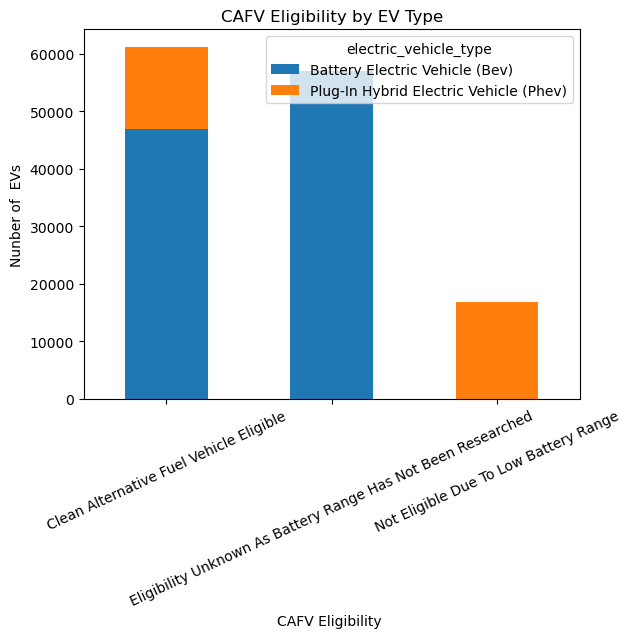

In [165]:
cafv_evtype.plot(kind="bar",stacked= True)
plt.xticks(rotation = 25)
plt.xlabel("CAFV Eligibility ")
plt.ylabel("Nunber of  EVs")
plt.title("CAFV Eligibility by EV Type")
plt.show()

INSIGHT:

--CAFV-eligible vehicles have siginificantly higher adoption

--BEVs benefit more from policy incentives than PHEVs

RECOMMENDATION:

--Policymakers: Expand CAFV Eligibility

--Reduce ambiguity in "Eligibility Unknown" Cases

Manufacturers:

--Design vehicles to meet CAFV reqirement intentinally

Takeaways:

-- Policy incentives are major driver of EV adoption

EDA - QUESTION - 6 ----- EV Adoption Across Legislative Districts

In [166]:
district_counts = data["legislative_district"].value_counts()
district_counts.head(11)

legislative_district
41    9035
45    8353
48    7637
36    5961
1     5746
5     5669
46    5433
43    5320
11    4575
37    4137
34    4039
Name: count, dtype: int64

In [167]:
district_counts_clean = district_counts.drop("Unknown",errors="ignore")

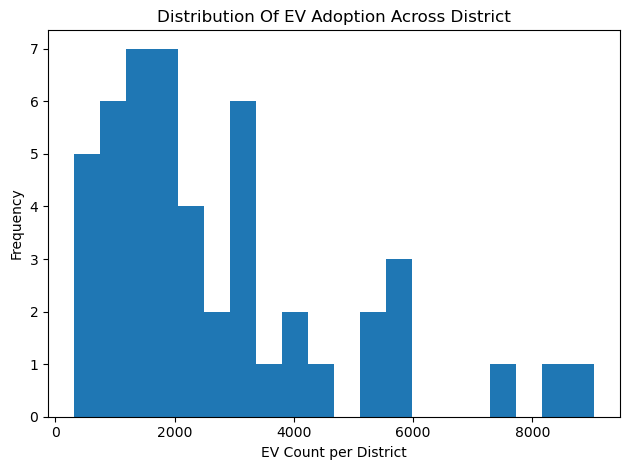

In [174]:
plt.figure()
district_counts_clean.plot(kind="hist",bins=20)
plt.xlabel("EV Count per District")
plt.title("Distribution Of EV Adoption Across District")
plt.tight_layout()
plt.show()

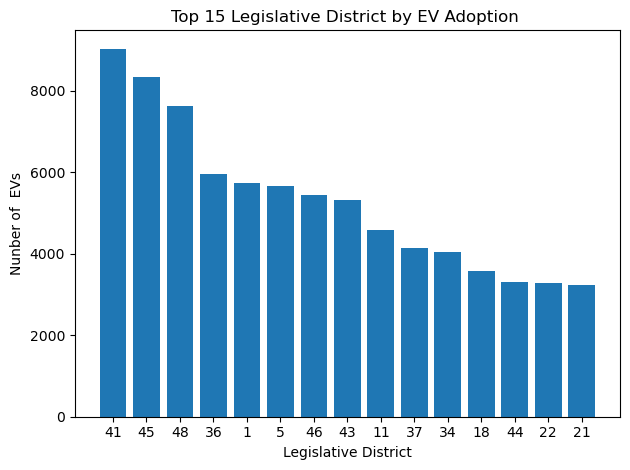

In [173]:
plt.figure()
plt.bar(
    district_counts_clean.index[:15],
    district_counts_clean.values[:15]
)
plt.xlabel("Legislative District")
plt.ylabel("Nunber of  EVs")
plt.title("Top 15 Legislative District by EV Adoption ")
plt.tight_layout()
plt.show()

INSIGHT:

--EV Adoption is uneven across districts

--Asmall number of districts account for a large share of EVs

RECOMMENDATION:

--Governament should Traget low-adoption districts with subsildes and infrastructure

--use high-adoption districts as policy success benchmarks

